In [1]:
import pandas as pd

url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(url_red, sep=";")
white = pd.read_csv(url_white, sep=";")

Encode color variable to 0/1, the concat the datasets

In [2]:
red["color"] = 0
white["color"] = 1
wine = pd.concat([red, white], ignore_index=True)
wine = wine.sample(frac=1, random_state=1234).reset_index(drop=True)
wine.shape

(6497, 13)

In [3]:
X = wine.drop("quality", axis=1)
y = wine["quality"]
X.shape, y.shape

((6497, 12), (6497,))

In [4]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
0,6.0,0.33,0.20,1.80,0.031,49.0,159.0,0.99190,3.41,0.53,11.0,1
1,7.2,0.29,0.20,7.70,0.046,51.0,174.0,0.99582,3.16,0.52,9.5,1
2,6.7,0.47,0.29,4.75,0.034,29.0,134.0,0.99056,3.29,0.46,13.0,1
3,7.6,0.43,0.31,2.10,0.069,13.0,74.0,0.99580,3.26,0.54,9.9,0
4,6.8,0.68,0.09,3.90,0.068,15.0,29.0,0.99524,3.41,0.52,11.1,0


In [5]:
from sklearn.model_selection import train_test_split

seed = 1234

# first split test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

# split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_train_full,
)

scale X

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# y stays same

Training set shape: (3897, 12) (3897,)
Validation set shape: (1300, 12) (1300,)
Test set shape: (1300, 12) (1300,)

Quality label distribution in full dataset:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


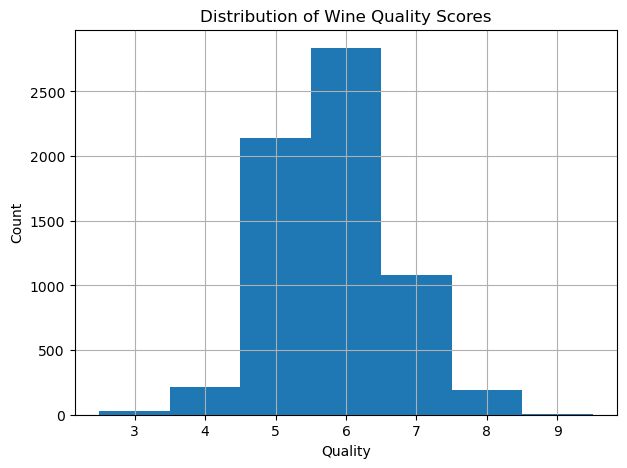

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


print("Training set shape:", X_train_scaled.shape, y_train.shape)
print("Validation set shape:", X_val_scaled.shape, y_val.shape)
print("Test set shape:", X_test_scaled.shape, y_test.shape)

print("\nQuality label distribution in full dataset:")
print(wine["quality"].value_counts().sort_index())



plt.figure(figsize=(7, 5))
wine["quality"].hist(bins=np.arange(wine["quality"].min(), wine["quality"].max() + 2) - 0.5)
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality Scores")
plt.xticks(sorted(wine["quality"].unique()))
plt.show()



k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

results = []

best_k = None
best_val_acc = -1
best_model = None


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_train_pred = knn.predict(X_train_scaled)
    y_val_pred = knn.predict(X_val_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    results.append({
        "k": k,
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k
        best_model = knn





Validation results:
     k  train_accuracy  validation_accuracy
0    1        1.000000             0.582308
1    3        0.764434             0.541538
2    5        0.676931             0.523077
3    7        0.649731             0.552308
4    9        0.625609             0.536923
5   11        0.612779             0.525385
6   13        0.609187             0.532308
7   15        0.604824             0.542308
8   17        0.602002             0.546923
9   19        0.596869             0.543077
10  21        0.588915             0.548462

Best k = 1
Best validation accuracy = 0.5823076923076923


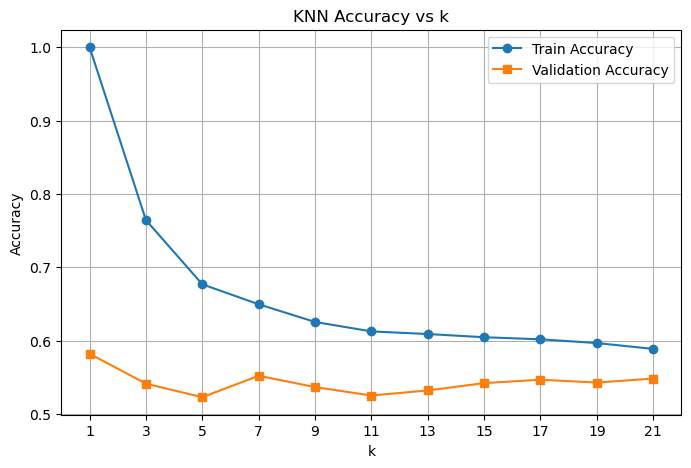


Final Test Results
Best k: 1
Test Accuracy: 0.6076923076923076


In [8]:



results_df = pd.DataFrame(results)
print("\nValidation results:")
print(results_df)

print("\nBest k =", best_k)
print("Best validation accuracy =", best_val_acc)



plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["train_accuracy"], marker='o', label="Train Accuracy")
plt.plot(results_df["k"], results_df["validation_accuracy"], marker='s', label="Validation Accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()



y_test_pred = best_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)

print("\nFinal Test Results")
print("Best k:", best_k)
print("Test Accuracy:", test_acc)





Confusion Matrix:


,0,1,2,3,4,5,6
0,0,2,3,1,0,0,0
1,1,12,22,5,3,0,0
2,3,17,285,111,11,1,0
3,3,5,118,359,71,11,0
4,0,4,19,69,117,6,1
5,0,0,1,9,12,17,0
6,0,0,0,0,1,0,0


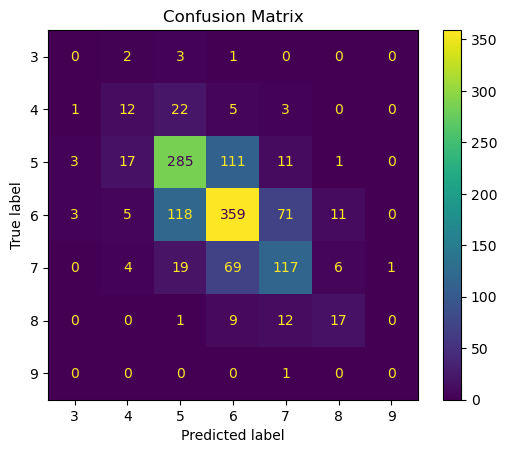


Classification Report:


,precision,recall,f1-score,support
3,0.0000,0.0000,0.0000,6.0000
4,0.3000,0.2791,0.2892,43.0000
5,0.6362,0.6659,0.6507,428.0000
6,0.6480,0.6332,0.6405,567.0000
7,0.5442,0.5417,0.5429,216.0000
8,0.4857,0.4359,0.4595,39.0000
9,0.0000,0.0000,0.0000,1.0000
accuracy,0.6077,0.6077,0.6077,0.6077
macro avg,0.3734,0.3651,0.3690,1300.0000
weighted avg,0.6070,0.6077,0.6071,1300.0000



Final Summary:


,Metric,Value
0,Best Validation Accuracy,0.5823
1,Test Accuracy,0.6077


In [9]:
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(cm)

print("\nConfusion Matrix:")
display(cm_df)


ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title("Confusion Matrix")
plt.show()


report_dict = classification_report(y_test, y_test_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\nClassification Report:")
display(report_df.round(4))



final_summary = pd.DataFrame({
    "Metric": ["Best Validation Accuracy", "Test Accuracy"],
    "Value": [best_val_acc, test_acc]
})

print("\nFinal Summary:")
display(final_summary.round(4))